This notebook contains additional model evaluation and compares model performance across sites and species.

In [1]:
from pathlib import Path
import zipfile

import joblib, os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy import stats

from ml_baselines.modelling.predict import predict_baselines
from ml_baselines.config import Config
from ml_baselines.data import read_agage
from ml_baselines.modelling.predict import load_baseline_model, BaselineLabelledObservations

cfg = Config()

import warnings
warnings.filterwarnings("ignore")

In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

## Coefficient of Variation

Loaded model from C:\Users\kirst\OneDrive\Kirstin\Uni\Year4\MSciProject\final_code\ml-baselines\models\MHD\mlp_model_2026-04-30_16-39_.joblib


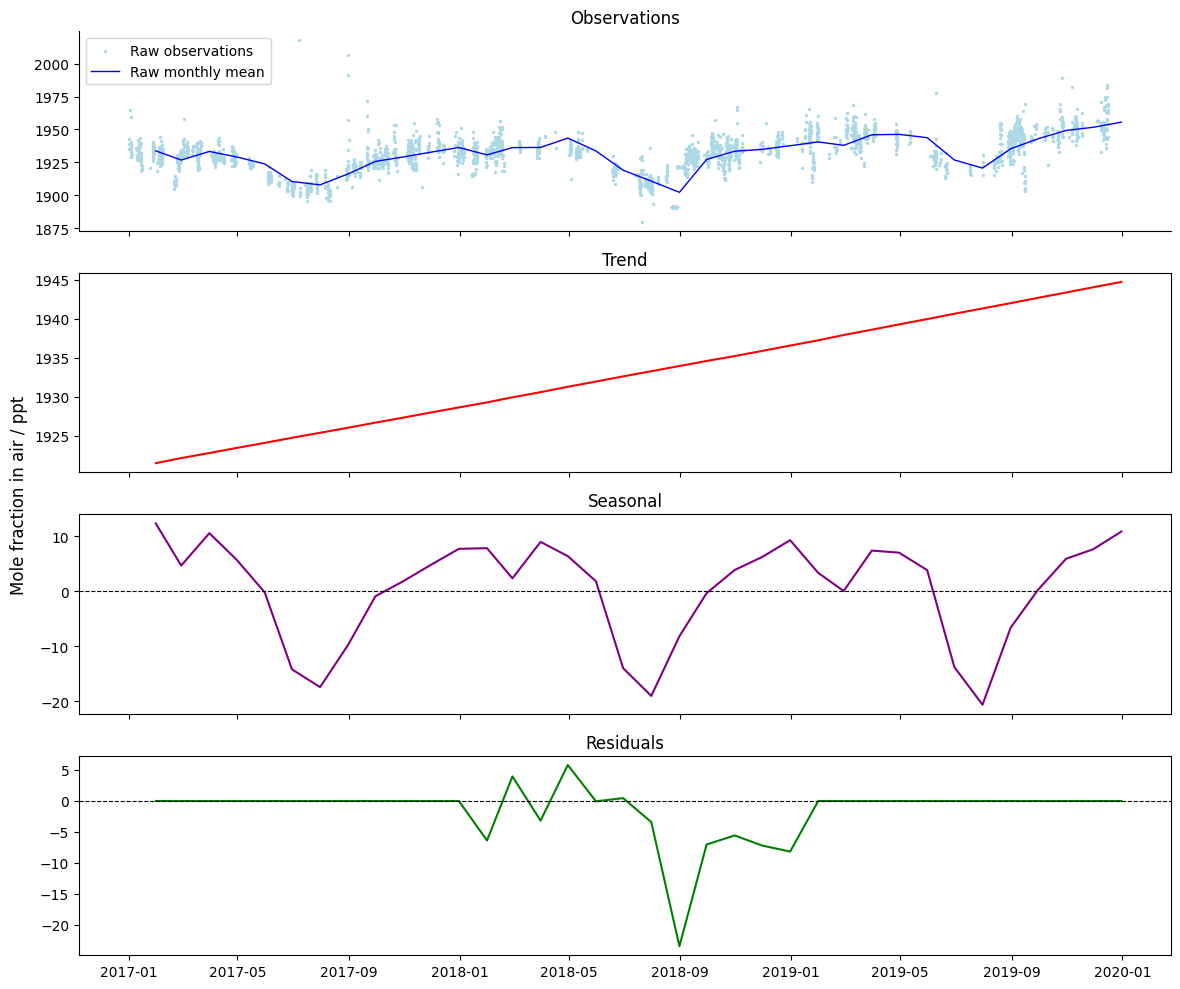

CV on train set for ch4 at MHD: 0.002


In [3]:
# explore one species
site = 'MHD'
species = 'ch4'
model_type = cfg.model_type

model, extra_info = model, extra_info = load_baseline_model(site, model_type, timestamp=None, suffix=None)
scaler = extra_info['scaler']
threshold = extra_info['model_inputs']['prediction_threshold']
y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                model=model, 
                                                scaler=scaler,
                                                prediction_mode="full", 
                                                prediction_threshold=threshold,
                                                return_proba=True,
                                                verbose=False)

df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])
labelled_obs_species = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
labelled_obs_species.calculate_true_baseline_cv(eval_mode="train", remove_seasonality=True, plot_stl=True, verbose=False) # plot seasonality decomposition as sanity check
print(f"CV on {labelled_obs_species.baseline_cv['eval_mode']} set for {species} at {site}: {labelled_obs_species.baseline_cv['cv']:.3f}")

Processing MHD...
   evaluating species...


Processing CGO...
   evaluating species...

Processing GSN...
   evaluating species...








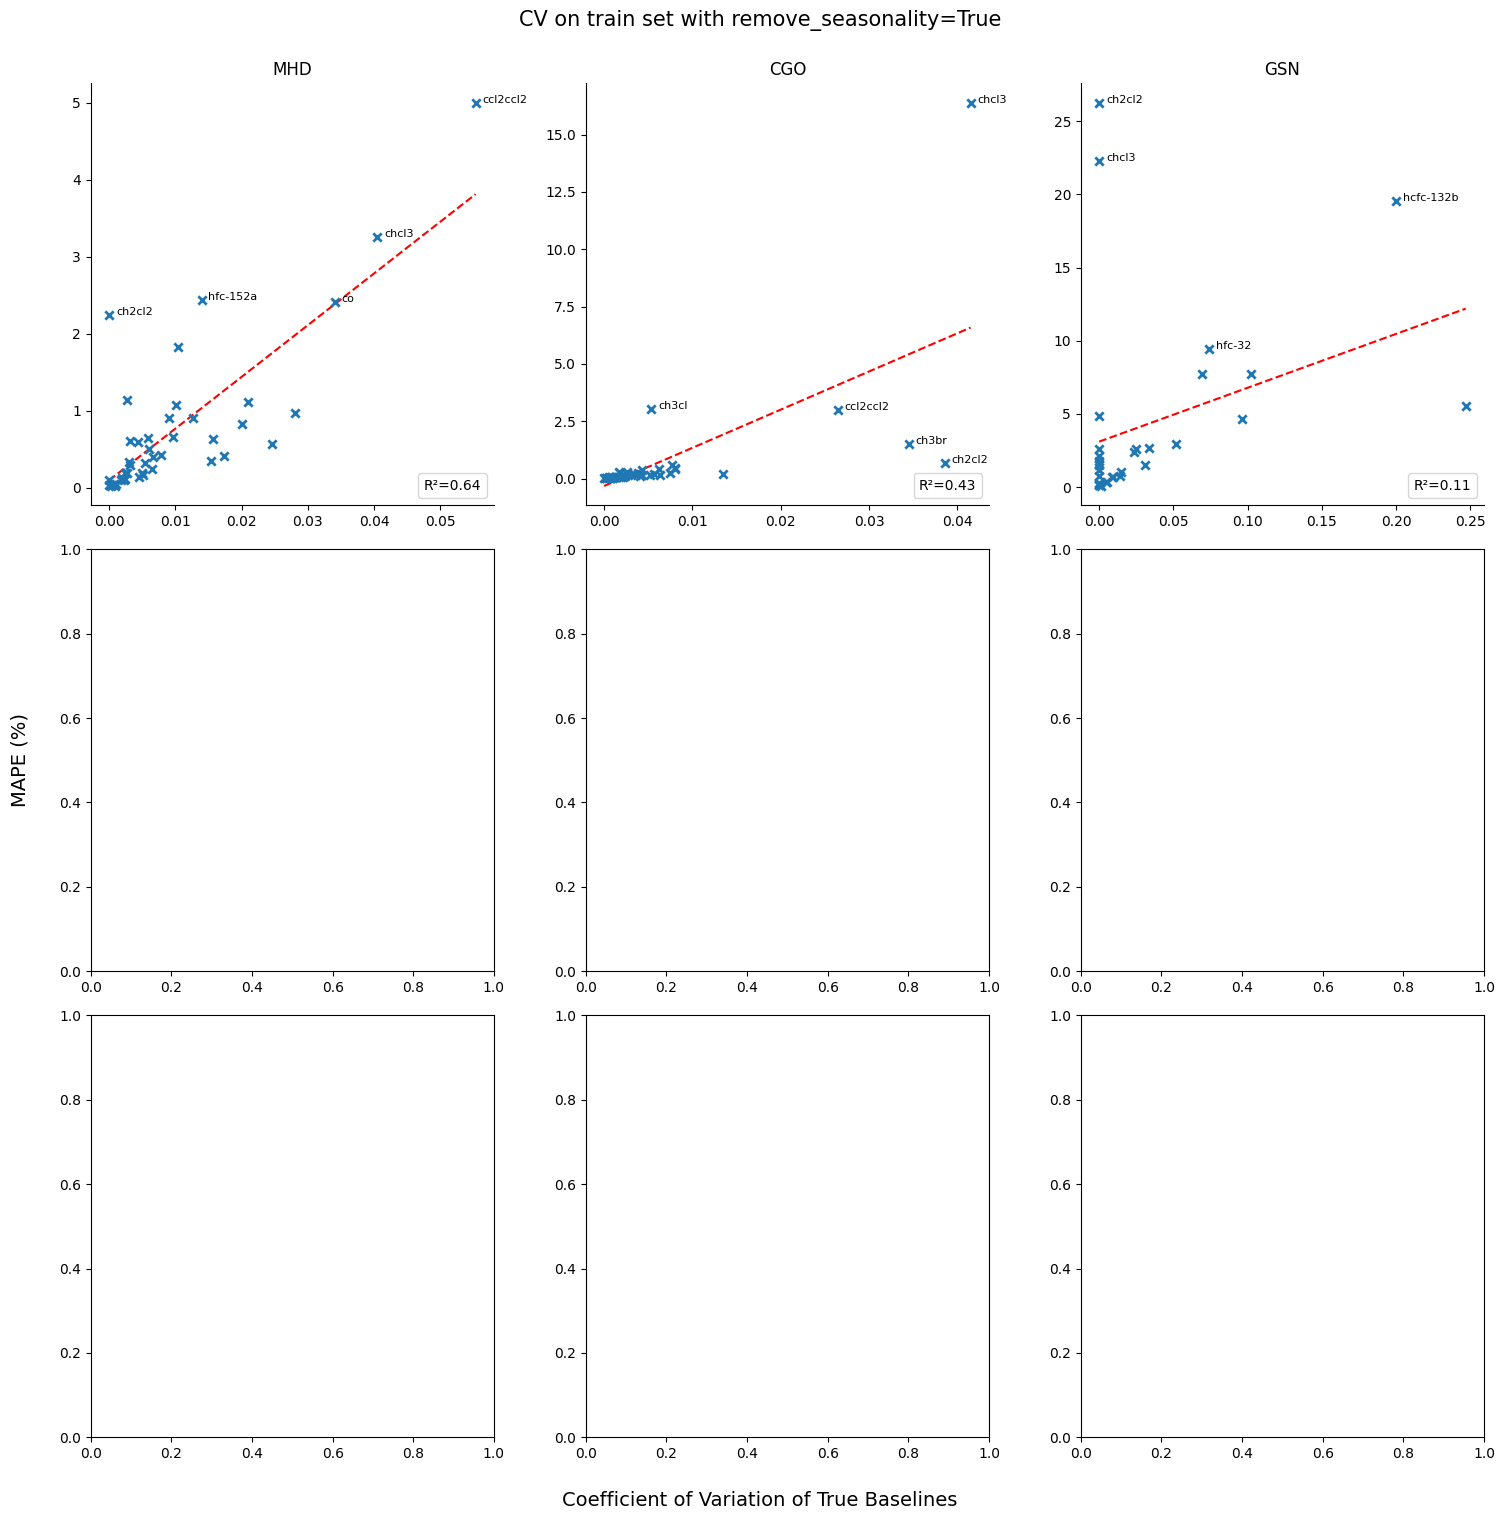

In [5]:
# loop through sites and species
sites = list(cfg.site_dict.keys())
model_type = cfg.model_type

cv_dict = {}
remove_seasonality = True
prediction_mode = "full"
eval_mode = "train"
cv_dict['eval_mode'] = eval_mode
for site in sites:
    try:
        model, extra_info = model, extra_info = load_baseline_model(site, model_type, timestamp=None, suffix=None, verbose=False)
    except:
         print("")
         continue
    print(f"Processing {site}...")
    cv_dict[site] = {}
    scaler = extra_info['scaler']
    threshold = extra_info['model_inputs']['prediction_threshold']

    y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                    model=model, 
                                                    scaler=scaler,
                                                    prediction_mode=prediction_mode, 
                                                    prediction_threshold=threshold,
                                                    return_proba=True,
                                                    verbose=False)

    with zipfile.ZipFile(Path(cfg.obs_path), 'r') as zf:
            all_files = zf.namelist()
            available = [(f.split('/')[0], f.split('_')[1].upper()) 
                        for f in all_files if f.endswith('.nc')]
            available_species = sorted(set([a[0] for a in available if a[1] == site.upper()]))

    num_low_coverage = 0
    print("   evaluating species...")
    for species in available_species:
        df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])
        try:
            labelled_obs_species = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
            labelled_obs_species.calculate_true_baseline_cv(eval_mode=eval_mode, remove_seasonality=remove_seasonality, verbose=False)
        except: 
            continue
        cv_dict[site][species] = {}
        baseline_cv = labelled_obs_species.baseline_cv['cv']
        cv_dict[site][species]['cv'] = baseline_cv
        if labelled_obs_species.baseline_cv['pct_monthly_coverage'] < 75:
            num_low_coverage += 1

        labelled_obs_species.print_monthly_stats(verbose=False)
        mape = labelled_obs_species.monthly_scores["test"]["MAPE"]
        cv_dict[site][species]['mape'] = mape.item()

    if num_low_coverage > 0 and remove_seasonality==True: 
        print(f"   {num_low_coverage}/{len(available_species)} of species had low coverage.\n") 
    else:
        print("")

# plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes_flat = axes.flatten()
for i, site in enumerate([s for s in cv_dict.keys() if s != 'eval_mode']):
    ax = axes_flat[i]
    species_list = [species for species in cv_dict[site]]
    cvs = [cv_dict[site][species]['cv'] for species in species_list]
    mapes = [100 * cv_dict[site][species]['mape'] for species in species_list]
    nan_count=0
   
    ax.scatter(cvs, mapes, marker='x', zorder=3, linewidth=2)

    threshold = np.percentile(mapes, 90)
    for species, x, y in zip(species_list, cvs, mapes):
        if y >= threshold:
            ax.annotate(species, (x, y), textcoords="offset points", xytext=(5, 0), fontsize=8)

    slope, intercept, r, _, _ = stats.linregress(cvs, mapes)
    x_line = np.linspace(min(cvs), max(cvs), 100)
    ax.plot(x_line, intercept + slope * x_line, color='red', linestyle='--', label=f'R²={r**2:.2f}')

    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(handlelength=0, handletextpad=0, loc="lower right")
    ax.set_title(f"{site}")

fig.supxlabel("Coefficient of Variation of True Baselines", fontsize=14, y=0)
fig.supylabel("MAPE (%)", fontsize=14, x=0)
fig.suptitle(f"CV on {cv_dict['eval_mode']} set with remove_seasonality={remove_seasonality}", fontsize=15, y=1.0)
fig.tight_layout()